---
title: "scikit-learn Users"
subtitle: "A quick guide to comparing classifiers' predictions with CompStats"
---

To illustrate the use of `CompStats`, the following example loads a classification problem (the digits dataset), trains four different classifiers, and uses `CompStats.metrics.f1_score` to measure and compare their performance. As with the rest of `sklearn.metrics`, the score function takes `(y_true, y_pred)`; the difference is that it returns a `Perf` instance, with the standard error, confidence interval, and pairwise significance tests already computed from the bootstrap distribution.

## Dataset and libraries

The first step is to load the digits dataset and split it into a training and a validation set.

In [1]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from CompStats.metrics import f1_score

X, y = load_digits(return_X_y=True)
_ = train_test_split(X, y, test_size=0.3)
X_train, X_val, y_train, y_val = _

## Linear SVM

The following line trains a linear Support Vector Machine and predicts the validation set's classes; the predictions are stored in `hy`.

In [2]:
m = LinearSVC().fit(X_train, y_train)
hy = m.predict(X_val)

## Score

Once the predictions are available, `f1_score` measures the classifier's performance. The API follows the `sklearn.metrics` convention -- the function takes `(y_true, y_pred)` -- but the result, `score`, is a `Perf` instance rather than a bare float.

In [3]:
score = f1_score(y_val, hy, name='Linear SVM', average='macro')
score

<Perf(func=f1_score, statistic=0.9576, se=0.0088)>

## Random Forest

Comparing a second classifier against the same gold standard reuses the same bootstrap resamples: calling `score` with a new set of predictions adds them to the comparison without redrawing the bootstrap, keeping every pairwise comparison paired.

In [4]:
ens = RandomForestClassifier().fit(X_train, y_train)
score(ens.predict(X_val), name='Random Forest')

<Perf(func=f1_score)>
Statistic with its standard error (se)
statistic (se)
0.9832 (0.0058) <= Random Forest
0.9576 (0.0088) <= Linear SVM

## Rest of the classifiers

Adding a Naive Bayes classifier and a Histogram Gradient Boosting Tree completes the comparison; `Perf.plot` renders all four systems' performance together with their confidence intervals.

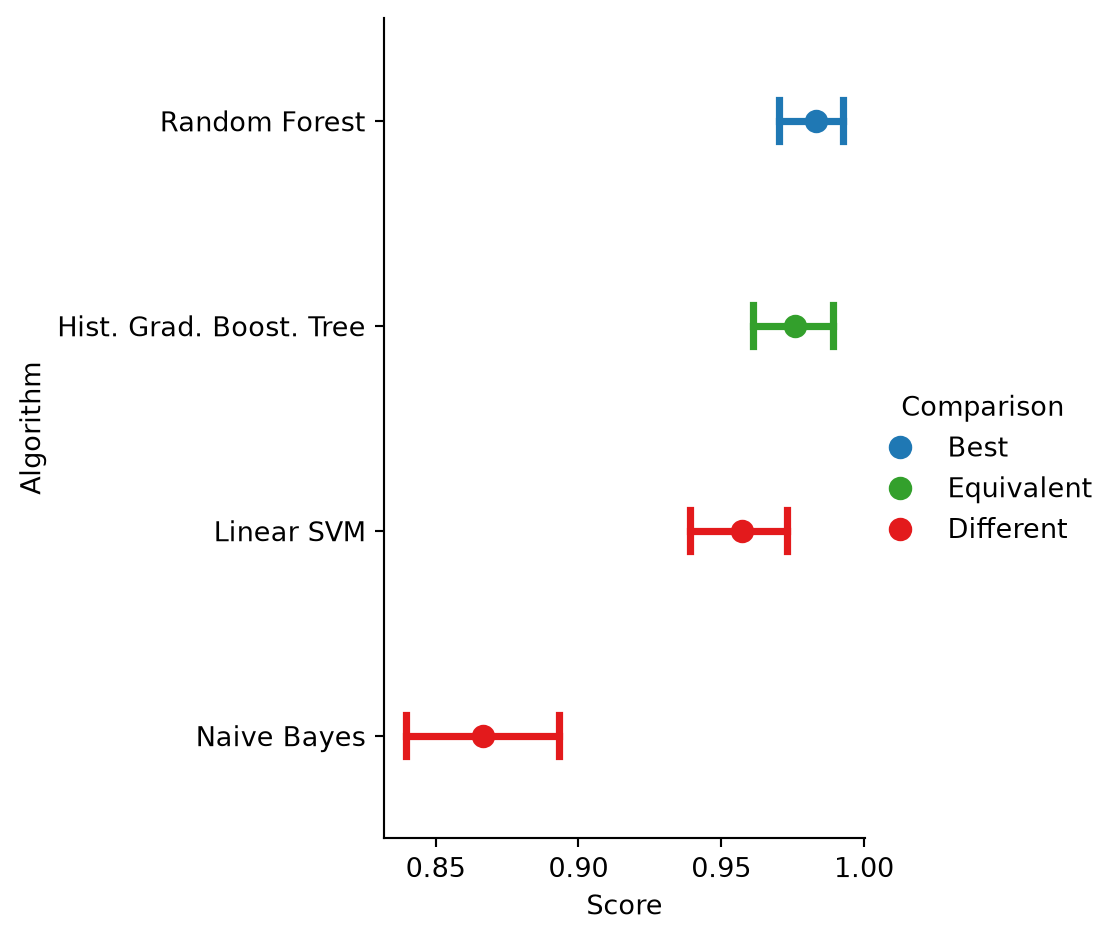

In [5]:
nb = GaussianNB().fit(X_train, y_train)
_ = score(nb.predict(X_val), name='Naive Bayes')
hist = HistGradientBoostingClassifier().fit(X_train, y_train)
_ = score(hist.predict(X_val), name='Hist. Grad. Boost. Tree')
score.plot()

[Competition Organizers](competition_organizers.ipynb) extends this workflow to ranking many participants against a gold standard, and [Multiple Testing](multiple_testing.ipynb) shows how to combine several measures in a single `Perf` and correct their p-values.